## Additional Materials
Used for disputation on Dec 19th 2025.

In [113]:
import pandas as pd
import matplotlib.pyplot as plt


In [114]:
df = pd.read_csv("/Users/andreamaldonado/Downloads/Metadata.csv")
print(df.shape, df.columns)
df.head()
real_df = df[df['Event Log Type']=='Real-life']#df[]
bpi_df = df[df['Event Log Name'].str.contains('bpi', case=False, na=False)]

(98, 40) Index(['Event Log \r\n\r\nID', 'Event Log Name',
       'Event Log Dataset\r\n\r\nFile Name', 'Event Log  \r\n\r\nYear',
       'Dataset Size', 'Dataset \r\n\r\nFormat', 'Number of \r\n\r\nCases',
       'Number of \r\n\r\nVariants', 'Number of \r\n\r\nEvents',
       'Number of \r\n\r\nActivities',
       'Number of \r\n\r\nAdditional \r\n\r\nAttributes',
       'Additional\r\n\r\nAttributes', 'Resource \r\n\r\nAvailability',
       'Median Case \r\n\r\nDuration', 'Mean Case \r\n\r\nDuration',
       'Start Date', 'End Date', 'Notes', 'Domain Application',
       'Event Log Type', 'Process Type', 'Process \r\n\r\nInformation',
       'DOI Number', 'Year', 'Publication Type', 'Reference', 'Activity Label',
       'Activity Label \r\n\r\nDescription',
       'Variant Proportion\r\n\r\nRatio\r\n\r\n',
       'Case Coverage \r\n\r\n(Top 5 Variants)',
       '% Case Coverage \r\n\r\n(Top 5 Variants)',
       'Mean Duration \r\n\r\n(Top 5 Variants)',
       'Potential \r\n\r\nPerfo

In [115]:
df.columns = (
    df.columns
      .str.replace('\n', '', regex=False)
      .str.replace('\r', '', regex=False)
      .str.strip()
)
print(df.columns[3])

df['Event Log Year'] = pd.to_numeric(df.columns[3], errors='coerce')
datasets_per_year = (
    df.groupby('Event Log Year')
      .size()
      .sort_index()
)

Event Log  Year


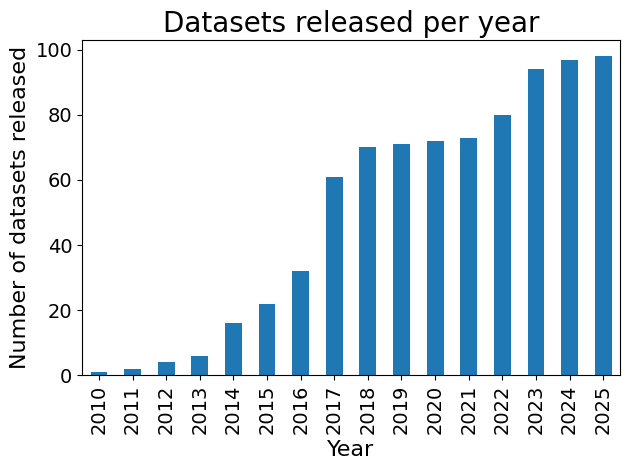

In [116]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = (
    df.columns
      .str.replace('\n', ' ', regex=False)
      .str.replace('\r', ' ', regex=False)
      .str.strip()
)

year_col = [c for c in df.columns if "Year" in c and "Event" in c]
year_col = year_col[0]

# Convert to numeric
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')

# Drop missing years
df_year = df.dropna(subset=[year_col])

#print("\nNon-null year count:", df_year.shape[0])

# Group and count
datasets_per_year = (
    df_year.groupby(year_col)
           .size()
           .sort_index()
)

cumulative_datasets = datasets_per_year.cumsum()

#print("\nGrouped result:")
#print(datasets_per_year)

# ---- Plot only if data exists ----
if not cumulative_datasets.empty:
    plt.figure()
    cumulative_datasets.plot(kind='bar')
    plt.xlabel("Year")
    plt.ylabel("Number of datasets released")
    plt.title("Datasets released per year")
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot — year column is empty.")


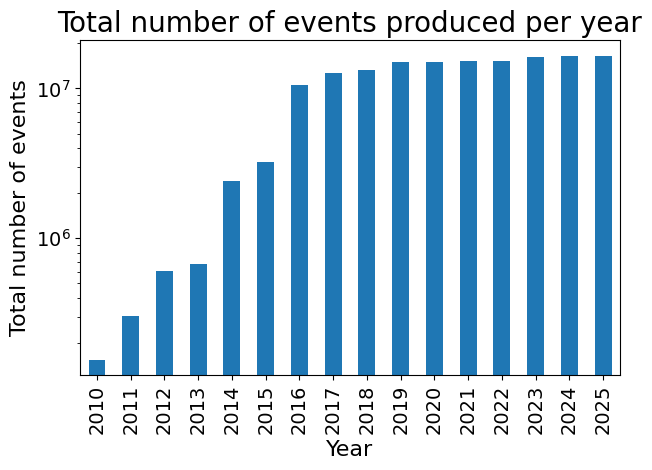

In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean column names
df.columns = (
    df.columns
      .str.replace('\n', ' ', regex=False)
      .str.replace('\r', ' ', regex=False)
      .str.strip()
)

# Detect columns
year_col = [c for c in df.columns if "Year" in c and "Event Log" in c][0]
events_col = [c for c in df.columns if "Number of" in c and "Events" in c][0]

# Convert to numeric
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
df[events_col] = pd.to_numeric(df[events_col], errors='coerce')

# Drop rows without valid year or event count
df_clean = df.dropna(subset=[year_col, events_col])

# Aggregate: total events per year
events_per_year = (
    df_clean.groupby(year_col)[events_col]
            .sum()
            .sort_index()
)
cumulative_events_per_year = events_per_year.cumsum()


# Plot
if not cumulative_events_per_year.empty:
    plt.figure()
    cumulative_events_per_year.plot(kind='bar')
    #plt.ylim(1e4, 1e7)
    plt.yscale('log')
    plt.xlabel("Year")
    plt.ylabel("Total number of events")
    plt.title("Total number of events produced per year")
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")


In [118]:
df1 = pd.read_csv("/Users/andreamaldonado/Downloads/bpic_features.csv", sep =";")

In [119]:
df1.head

<bound method NDFrame.head of                                      log  year  n_traces  n_unique_traces  \
0                     BPI2016_Complaints  2016       226               99   
1                      BPI2016_Questions  2016     21533            17171   
2               BPI2016_Werkmap_Messages  2016     16653               48   
3                               BPIC15_1  2015      1199             1170   
4                               BPIC15_2  2015       832              828   
5                               BPIC15_3  2015      1409             1349   
6                               BPIC15_4  2015      1053             1049   
7                               BPIC15_5  2015      1156             1153   
8                     BPI_Challenge_2012  2012     13087             4366   
9     BPI_Challenge_2013_closed_problems  2013      1487              183   
10          BPI_Challenge_2013_incidents  2013      7554             1511   
11      BPI_Challenge_2013_open_problems  2013

In [120]:
print(df1.columns[:20])

Index(['log', 'year', 'n_traces', 'n_unique_traces',
       'ratio_unique_traces_per_trace', 'trace_len_min', 'trace_len_max',
       'trace_len_mean', 'trace_len_median', 'trace_len_mode', 'trace_len_std',
       'trace_len_variance', 'trace_len_q1', 'trace_len_q3', 'trace_len_iqr',
       'trace_len_geometric_mean', 'trace_len_geometric_std',
       'trace_len_harmonic_mean', 'trace_len_skewness', 'trace_len_kurtosis'],
      dtype='object')


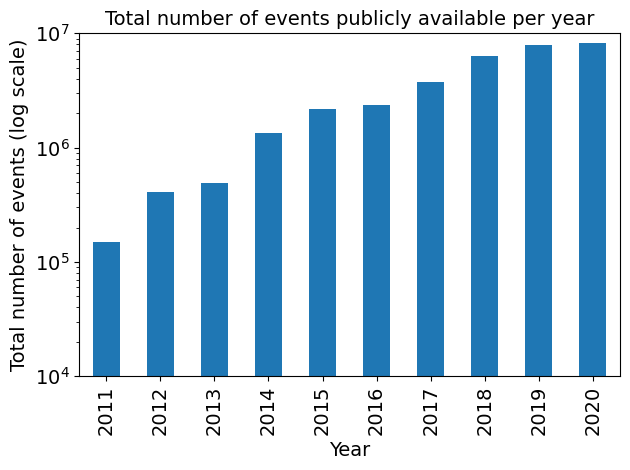

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure correct dtypes
df1['year'] = pd.to_numeric(df1['year'], errors='coerce')
df1['n_traces'] = pd.to_numeric(df1['n_traces'], errors='coerce')
df1['trace_len_mean'] = pd.to_numeric(df1['trace_len_mean'], errors='coerce')

# Drop invalid rows
df_clean = df1.dropna(subset=['year', 'n_traces', 'trace_len_mean'])

# Estimate total events per log
df_clean['total_events'] = df_clean['n_traces'] * df_clean['trace_len_mean']

# Aggregate total events per year
events_per_year = (
    df_clean.groupby('year')['total_events']
            .sum()
            .sort_index()
)
cumulative_events_per_year = events_per_year.cumsum()

plt.rcParams.update({
    'axes.titlesize': 14,      # title font size
    'axes.labelsize': 14,      # x and y label font size
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 14      # legend font size
})

# Plot (log scale, capped at 10^7)
plt.figure()
cumulative_events_per_year.plot(kind='bar')
plt.yscale('log')
plt.ylim(1e4, 1e7)
plt.xlabel("Year")
plt.ylabel("Total number of events (log scale)")
plt.title("Total number of events publicly available per year")
plt.tight_layout()
plt.show()

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_42278/3865241640.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df[year_col] = pd.to_numeric(real_df[year_col], errors='coerce')
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_42278/3865241640.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df[events_col] = pd.to_numeric(real_df[events_col], errors='coerce')
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_42278/3865241640.py:64: SettingWithCopyWarning: 
A 

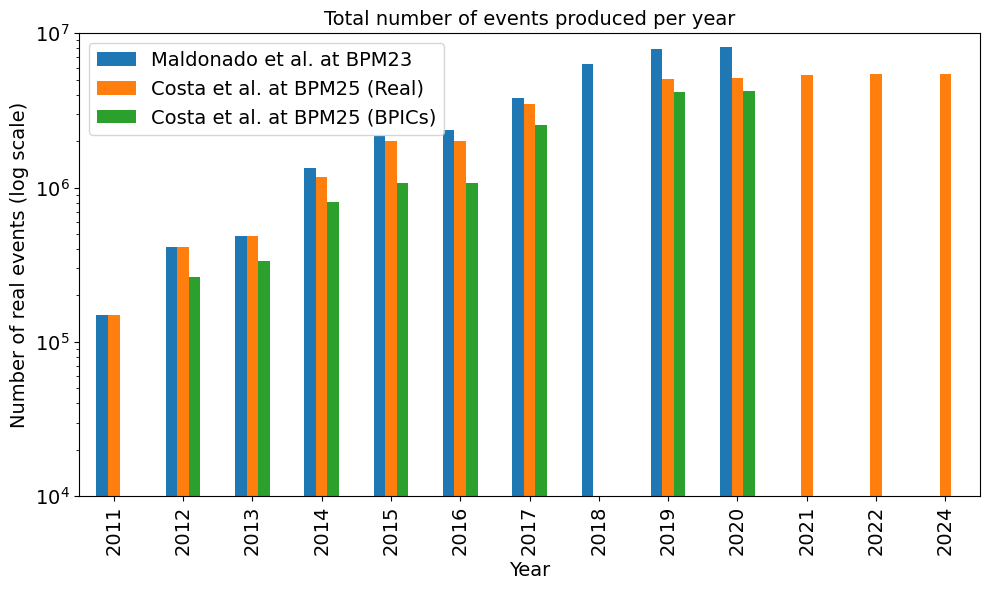

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Dataset 1 ---
# Clean column names
df.columns = df.columns.str.replace('\n', ' ', regex=False)\
                       .str.replace('\r', ' ', regex=False)\
                       .str.strip()

# Detect columns
year_col = [c for c in df.columns if "Year" in c and "Event Log" in c][0]
events_col = [c for c in df.columns if "Number of" in c and "Events" in c][0]

# Convert to numeric and drop invalid rows
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
df[events_col] = pd.to_numeric(df[events_col], errors='coerce')
df_clean1 = df.dropna(subset=[year_col, events_col])

# Aggregate total events per year
events_per_year1 = df_clean1.groupby(year_col)[events_col].sum()
cumulative_events_per_year1 = events_per_year1.cumsum()


# --- Dataset 2 ---
# Ensure correct dtypes and drop invalid rows
df1['year'] = pd.to_numeric(df1['year'], errors='coerce')
df1['n_traces'] = pd.to_numeric(df1['n_traces'], errors='coerce')
df1['trace_len_mean'] = pd.to_numeric(df1['trace_len_mean'], errors='coerce')
df_clean2 = df1.dropna(subset=['year', 'n_traces', 'trace_len_mean'])

# Estimate total events and aggregate
df_clean2['total_events'] = df_clean2['n_traces'] * df_clean2['trace_len_mean']
events_per_year2 = df_clean2.groupby('year')['total_events'].sum()
cumulative_events_per_year2 = events_per_year2.cumsum()

# Dataset 3
real_df.columns = real_df.columns.str.replace('\n', ' ', regex=False)\
                       .str.replace('\r', ' ', regex=False)\
                       .str.strip()

# Detect columns
year_col = [c for c in real_df.columns if "Year" in c and "Event Log" in c][0]
events_col = [c for c in real_df.columns if "Number of" in c and "Events" in c][0]

# Convert to numeric and drop invalid rows
real_df[year_col] = pd.to_numeric(real_df[year_col], errors='coerce')
real_df[events_col] = pd.to_numeric(real_df[events_col], errors='coerce')
df_clean3 = real_df.dropna(subset=[year_col, events_col])

# Aggregate total events per year
events_per_year3 = df_clean3.groupby(year_col)[events_col].sum()
cumulative_events_per_year3 = events_per_year3.cumsum()

# Dataset 4
bpi_df.columns = bpi_df.columns.str.replace('\n', ' ', regex=False)\
                       .str.replace('\r', ' ', regex=False)\
                       .str.strip()

# Detect columns
year_col = [c for c in bpi_df.columns if "Year" in c and "Event Log" in c][0]
events_col = [c for c in bpi_df.columns if "Number of" in c and "Events" in c][0]

# Convert to numeric and drop invalid rows
bpi_df[year_col] = pd.to_numeric(bpi_df[year_col], errors='coerce')
bpi_df[events_col] = pd.to_numeric(bpi_df[events_col], errors='coerce')
df_clean4 = bpi_df.dropna(subset=[year_col, events_col])

# Aggregate total events per year
events_per_year4 = df_clean4.groupby(year_col)[events_col].sum()
cumulative_events_per_year4 = events_per_year4.cumsum()

# --- Combine into one DataFrame ---
combined = pd.DataFrame({
    'Maldonado et al. at BPM23': cumulative_events_per_year2,
    #'Costa et al. at BPM25': cumulative_events_per_year1,
    'Costa et al. at BPM25 (Real)': cumulative_events_per_year3,
    'Costa et al. at BPM25 (BPICs)': cumulative_events_per_year4,
    
}).fillna(0)  # fill missing years with 0

plt.rcParams.update({
    'axes.titlesize': 14,      # title font size
    'axes.labelsize': 14,      # x and y label font size
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 14      # legend font size
})

# --- Plot combined bar chart ---
combined.plot(kind='bar', logy=True, figsize=(10,6))
plt.ylim(1e4, 1e7)
plt.xlabel("Year")
plt.ylabel("Number of real events (log scale)")
plt.title("Total number of events produced per year")
plt.tight_layout()
plt.show()

/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_42278/2611988836.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df[year_col1] = pd.to_numeric(real_df[year_col1], errors='coerce')
/var/folders/d0/btmbyskx4t106_l2zghzln2w0000gn/T/ipykernel_42278/2611988836.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bpi_df[year_col1] = pd.to_numeric(bpi_df[year_col1], errors='coerce')


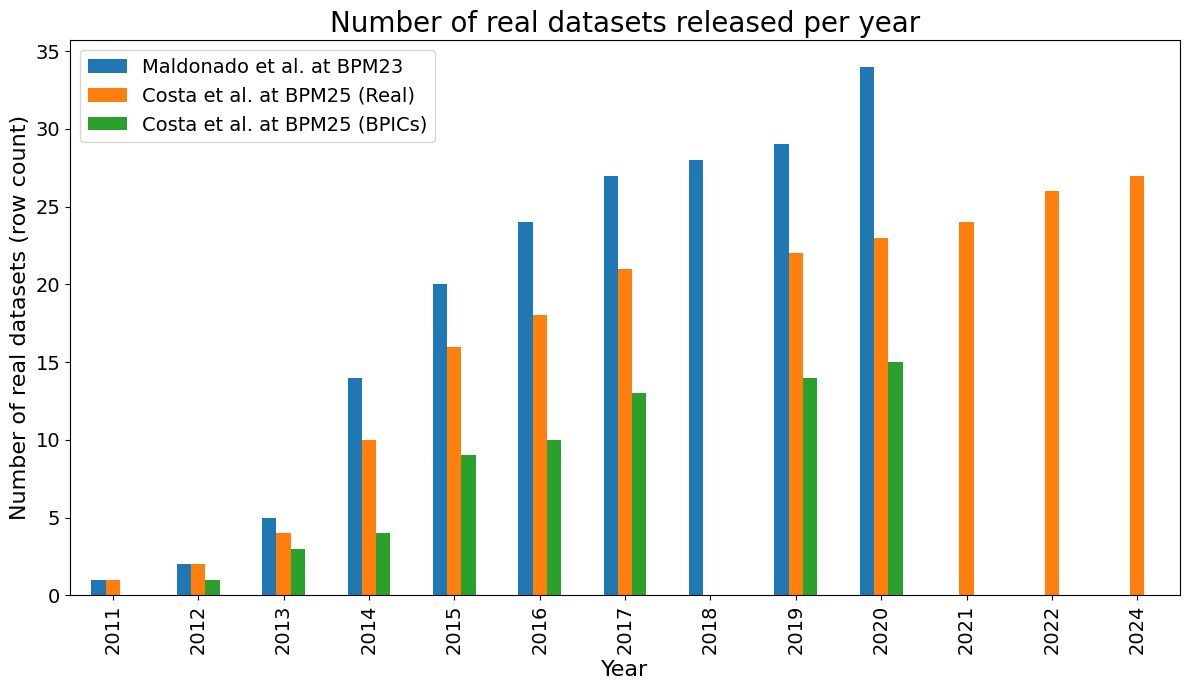

In [128]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Dataset 1 ---
df.columns = df.columns.str.replace('\n', ' ', regex=False)\
                       .str.replace('\r', ' ', regex=False)\
                       .str.strip()
year_col1 = [c for c in df.columns if "Year" in c and "Event" in c][0]
df[year_col1] = pd.to_numeric(df[year_col1], errors='coerce')
df_clean1 = df.dropna(subset=[year_col1])
logs_per_year1 = df_clean1.groupby(year_col1).size().sort_index()
cumulative_logs_per_year1 = logs_per_year1.cumsum()

# --- Dataset 3 ---
real_df.columns = real_df.columns.str.replace('\n', ' ', regex=False)\
                       .str.replace('\r', ' ', regex=False)\
                       .str.strip()
year_col1 = [c for c in real_df.columns if "Year" in c and "Event" in c][0]
real_df[year_col1] = pd.to_numeric(real_df[year_col1], errors='coerce')
df_clean3 = real_df.dropna(subset=[year_col1])
logs_per_year3 = df_clean3.groupby(year_col1).size().sort_index()
cumulative_logs_per_year3 = logs_per_year3.cumsum()

# --- Dataset 4 ---
bpi_df.columns = bpi_df.columns.str.replace('\n', ' ', regex=False)\
                       .str.replace('\r', ' ', regex=False)\
                       .str.strip()
year_col1 = [c for c in bpi_df.columns if "Year" in c and "Event" in c][0]
bpi_df[year_col1] = pd.to_numeric(bpi_df[year_col1], errors='coerce')
df_clean4 = bpi_df.dropna(subset=[year_col1])
logs_per_year4 = df_clean4.groupby(year_col1).size().sort_index()
cumulative_logs_per_year4 = logs_per_year4.cumsum()

# --- Dataset 2 ---
df1['year'] = pd.to_numeric(df1['year'], errors='coerce')
df_clean2 = df1.dropna(subset=['year'])
logs_per_year2 = df_clean2.groupby('year').size().sort_index()
cumulative_logs_per_year2 = logs_per_year2.cumsum()

# --- Combine ---
combined_logs = pd.DataFrame({
    'Maldonado et al. at BPM23': cumulative_logs_per_year2,
    #'Costa et al. at BPM25': cumulative_logs_per_year1,
    'Costa et al. at BPM25 (Real)': cumulative_logs_per_year3,
    'Costa et al. at BPM25 (BPICs)': cumulative_logs_per_year4,
}).fillna(0)

# --- Bigger fonts ---
plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# --- Plot ---
ax = combined_logs.plot(kind='bar', figsize=(12,7))
plt.xlabel("Year")
plt.ylabel("Number of real datasets (row count)")
plt.title("Number of real datasets released per year")
plt.tight_layout()
plt.show()


In [68]:
df_clean1[df_clean1[year_col]>=2021].sort_values(year_col)[['Event Log Name',year_col]]

,Event Log Name,Event Log Year
22,Event log belonging to the publication: Proces...,2021
29,Receipt phase of an environmental permit appli...,2022
55,Sepsis Treatment Careflow,2022
88,microsoft/50BusinessAssignmentsLog,2024
